In [1]:
import os
import gymnasium as gym
import pandas as pd
from skopt.space import Real
from multiprocessing import Pool
from tqdm import tqdm


from popy.simulation_tools import *
from popy.io_tools import load_behavior, load_behavior_yuri
from popy.behavior_data_tools import *
from popy.plotting.plotting_tools import *
from popy.config import PROJECT_PATH_LOCAL

from popy.simulation_helpers import fit_simulate, simulate_agent
from popy.plotting.plotting_tools import show_target_selection, show_target_selection_compact

MODELS = {
    "Repeating agent": {
        "agent_class": RepeatingAgent,
        "fixed_params": {},
        "free_params": ["epsilon"],
    },

    "WSLS": {
        "agent_class": WSLSAgent,
        "fixed_params": {},
        "free_params": ["epsilon"],
    },

    "Standard RL": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": False},
        "free_params": ["alpha", "beta"],
    },
    "Standard RL - stickiness": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": False},
        "free_params": ["alpha", "beta", "stickiness_bias"],
    },
    "Standard RL - forgetting": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": False},
        "free_params": ["alpha", "beta", "forgetting_rate", "forgetting_threshold"],
    },
    "Standard RL - stickiness + forgetting": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": False},
        "free_params": ["alpha", "beta", "forgetting_rate", "forgetting_threshold", "stickiness_bias"],
    },

    "Inferential RL": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": True},
        "free_params": ["alpha", "beta"],
    },
    "Inferential RL - stickiness": {    
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": True},
        "free_params": ["alpha", "beta", "stickiness_bias"],
    },
    "Inferential RL - stickiness + spatial bias": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": True},
        "free_params": ["alpha", "beta", "stickiness_bias", "b2_bias"],
    },
    "Inferential RL - stickiness + multiple alphas": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": True},
        "free_params": ["alpha", "alpha_unchosen", "beta", "stickiness_bias"],
    },

    "Foraging - no reset": {
        "agent_class": ForagingAgent,
        "fixed_params": {"reset_on_switch": False},
        "free_params": ["alpha", "beta", "V0"],
    },
    "Foraging": {
        "agent_class": ForagingAgent,
        "fixed_params": {"reset_on_switch": True},
        "free_params": ["alpha", "beta", "V0"],
    },
    "Foraging - abandoned bias": {
        "agent_class": ForagingAgent,
        "fixed_params": {"reset_on_switch": True},
        "free_params": ["alpha", "beta",  "V0", "abandoned_bias", "abandoned_decay"],
    },
    "Foraging - abandoned bias + spatial bias": {
        "agent_class": ForagingAgent,
        "fixed_params": {"reset_on_switch": True},
        "free_params": ["alpha", "beta",  "V0", "abandoned_bias", "abandoned_decay", "b2_bias"],
    },
    "Foraging - adaptive threshold": {
        "agent_class": ForagingAgentAdaptive,
        "fixed_params": {'alpha_threshold': 0.05},
        "free_params": [],
    },
    "HMMAgent": {
        "agent_class": HMMAgent,
        "fixed_params": {},
    },
    "HSMMAgent": {
        "agent_class": HSMMAgent,
        "fixed_params": {},
    },
}

/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-_u867eay because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


LPT for ka: 0.511
-16104.000551939524
LPT for ka: 0.514
-15942.737120584166
LPT for ka: 0.517
-15810.768703848637
LPT for ka: 0.519
-15706.555573985494
LPT for ka: 0.521
-15628.57191191665
LPT for ka: 0.522
-15575.316497862852
LPT for ka: 0.523
-15545.32302451185
LPT for ka: 0.523
-15537.169192776597
LPT for ka: 0.522
-15549.482658073819
LPT for ka: 0.522
-15580.946503118194
LPT for ka: 0.521
-15630.302788600839
LPT for ka: 0.519
-15696.354852185166
LPT for ka: 0.518
-15777.968460403896
LPT for ka: 0.515
-15874.072945960379
LPT for ka: 0.513
-15983.659484278924
LPT for ka: 0.510
-16105.780588262296
LPT for ka: 0.508
-16239.549355779356
LPT for ka: 0.505
-16384.13585457257
LPT for ka: 0.501
-16538.765495505697
LPT for ka: 0.498
-16702.71759336493


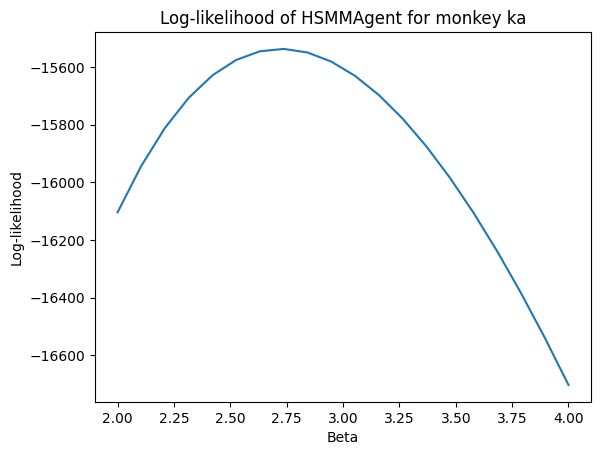

In [21]:
from popy.simulation_helpers import estimate_ll

behavs = []
model_name = "HSMMAgent"

env = gym.make(
    "zsombi/monkey-bandit-task-v0",
    n_arms=3,
)

"""Optimize a single model and return results."""
model_params = MODELS[model_name]

agent_class = model_params["agent_class"]
fixed_params = model_params["fixed_params"]
params = {'beta': 5}

behav_data = load_behavior("ka")
behav_data = convert_column_format(behav_data, original="behavior")

beta_grid = np.linspace(2, 4, 20)
res = []
for beta in beta_grid:
    params['beta'] = beta
    ll = estimate_ll(agent_class, params, behav_data, fixed_params, return_with_behav=False)
    lpt = np.exp(ll / len(behav_data))
    print(f"LPT for ka: {lpt:.3f}")
    print(ll)
    res.append((beta, ll, lpt))

plt.plot(beta_grid, [r[1] for r in res])
plt.xlabel("Beta")
plt.ylabel("Log-likelihood")
plt.title(f"Log-likelihood of {model_name} for monkey ka")
plt.show()

In [16]:
behav_all = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'optimizing', f'simulation_behaviors.pkl'))
behav_all

,model,session,trial_id,block_id,best_arm,action,reward
0,WSLS,0,0,0,2,0,0.0
1,WSLS,0,1,0,2,1,0.0
2,WSLS,0,2,0,2,0,0.0
3,WSLS,0,3,0,2,1,0.0
4,WSLS,0,4,0,2,2,1.0
...,...,...,...,...,...,...,...
1499995,Foraging - adaptive threshold,0,99995,2496,0,0,1.0
1499996,Foraging - adaptive threshold,0,99996,2496,0,0,0.0
1499997,Foraging - adaptive threshold,0,99997,2496,0,0,1.0
1499998,Foraging - adaptive threshold,0,99998,2496,0,0,1.0


In [ ]:

model_name = 'HSMMAgent'

env = gym.make(
    "zsombi/monkey-bandit-task-v0", 
    n_arms=3, 
    max_episode_steps=100_000,
)

"""Optimize a single model and return results."""
model_params = MODELS[model_name]

agent_class = model_params["agent_class"]
fixed_params = model_params["fixed_params"]
params = {}

# Simulate behavior with best parameters
behav = simulate_agent(
    agent_class=agent_class, 
    params=params,
    env=env, 
    fixed_params=fixed_params, 
    behavioral_variables=[],
    verbose=False
)
reward_rate = behav['reward'].mean()
proba_best = (behav['action'] == behav['best_arm']).mean()

# Compute log-likelihood of the simulated behavior under the model
for monkey in ['ka', 'po']:
    behav_data = load_behavior(monkey)
    behav_data = convert_column_format(behav_data, original="behavior")
    ll = estimate_ll(
        agent_class, params, behav_data, fixed_params, return_with_behav=False
    )
    lpt = -ll / len(behav_data)
    print(f"Log-likelihood of simulated behavior under {model_name} for monkey {monkey}: {ll:.2f}")

print("Model", model_name)
print(f"Simulated behavior with model: {model_name}")
print(f"Reward rate: {reward_rate:.3f}")
print(f"Proba. choosing best target: {proba_best:.3f}")

# keep only models in agents_to_show.keys() and renaming them
behav['model'] = model_name

# Apply the function to create the monkey column
behav['session'] = 0




Log-likelihood of simulated behavior under HSMMAgent for monkey ka: -288125.90
Log-likelihood of simulated behavior under HSMMAgent for monkey po: -356274.71
Model HSMMAgent
Simulated behavior with model: HSMMAgent
Reward rate: 0.638
Proba. choosing best target: 0.887


In [18]:
# concat with real behavior
behav_all = pd.concat([behav_all, behav], ignore_index=True)

# count per model
model_counts = behav_all['model'].value_counts()
print(model_counts)

behav_all

model
WSLS                                             100000
Repeating agent                                  100000
Standard RL - stickiness                         100000
Standard RL                                      100000
Standard RL - forgetting                         100000
Inferential RL - stickiness + spatial bias       100000
Standard RL - stickiness + forgetting            100000
Inferential RL - stickiness + multiple alphas    100000
Foraging                                         100000
Inferential RL - stickiness                      100000
Inferential RL                                   100000
Foraging - no reset                              100000
Foraging - abandoned bias                        100000
Foraging - abandoned bias + spatial bias         100000
Foraging - adaptive threshold                    100000
HSMMAgent                                        100000
Name: count, dtype: int64


,model,session,trial_id,block_id,best_arm,action,reward,monkey
0,WSLS,0,0,0,2,0,0.0,NaN
1,WSLS,0,1,0,2,1,0.0,NaN
2,WSLS,0,2,0,2,0,0.0,NaN
3,WSLS,0,3,0,2,1,0.0,NaN
4,WSLS,0,4,0,2,2,1.0,NaN
...,...,...,...,...,...,...,...,...
1599995,HSMMAgent,0,99995,2496,0,0,0.0,HSMMAgent
1599996,HSMMAgent,0,99996,2496,0,0,1.0,HSMMAgent
1599997,HSMMAgent,0,99997,2496,0,0,1.0,HSMMAgent
1599998,HSMMAgent,0,99998,2496,0,0,1.0,HSMMAgent


In [21]:
# save back to original 
behav_all.to_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'optimizing', f'simulation_behaviors.pkl'))


In [3]:
from popy.simulation_helpers import estimate_ll


behavs = []
for model_name in ['HSMMAgent', 'HMMAgent']:

    env = gym.make(
        "zsombi/monkey-bandit-task-v0", 
        n_arms=3, 
        max_episode_steps=10_000,
    )

    """Optimize a single model and return results."""
    model_params = MODELS[model_name]

    agent_class = model_params["agent_class"]
    fixed_params = model_params["fixed_params"]
    params = {}

    # Simulate behavior with best parameters
    behav = simulate_agent(
        agent_class=agent_class, 
        params=params,
        env=env, 
        fixed_params=fixed_params, 
        behavioral_variables=[],
        verbose=False
    )
    reward_rate = behav['reward'].mean()
    proba_best = (behav['action'] == behav['best_arm']).mean()

    # Compute log-likelihood of the simulated behavior under the model
    for monkey in ['ka', 'po']:
        behav_data = load_behavior(monkey)
        behav_data = convert_column_format(behav_data, original="behavior")
        ll = estimate_ll(
            agent_class, params, behav_data, fixed_params, return_with_behav=False
        )
        lpt = -ll / len(behav_data)
        print(f"Log-likelihood of simulated behavior under {model_name} for monkey {monkey}: {ll:.2f}")

    print("Model", model_name)
    print(f"Simulated behavior with model: {model_name}")
    print(f"Reward rate: {reward_rate:.3f}")
    print(f"Proba. choosing best target: {proba_best:.3f}")

    # keep only models in agents_to_show.keys() and renaming them
    behav['model'] = model_name

    # Apply the function to create the monkey column
    behav['monkey'] = behav['model']
    behav['session'] = 0
    behavs.append(behav)

# Concatenate all behaviors into a single DataFrame
behavs_df = pd.concat(behavs, ignore_index=True)
behavs_df

Log-likelihood of simulated behavior under HSMMAgent for monkey ka: -288125.90
Log-likelihood of simulated behavior under HSMMAgent for monkey po: -356274.71
Model HSMMAgent
Simulated behavior with model: HSMMAgent
Reward rate: 0.633
Proba. choosing best target: 0.882
Log-likelihood of simulated behavior under HMMAgent for monkey ka: -194362.99
Log-likelihood of simulated behavior under HMMAgent for monkey po: -268746.42
Model HMMAgent
Simulated behavior with model: HMMAgent
Reward rate: 0.579
Proba. choosing best target: 0.807


,trial_id,block_id,best_arm,action,reward,model,monkey,session
0,0,0,2,1,0.0,HSMMAgent,HSMMAgent,0
1,1,0,2,2,1.0,HSMMAgent,HSMMAgent,0
2,2,0,2,2,1.0,HSMMAgent,HSMMAgent,0
3,3,0,2,2,0.0,HSMMAgent,HSMMAgent,0
4,4,0,2,2,1.0,HSMMAgent,HSMMAgent,0
...,...,...,...,...,...,...,...,...
19995,9995,250,0,0,0.0,HMMAgent,HMMAgent,0
19996,9996,250,0,0,1.0,HMMAgent,HMMAgent,0
19997,9997,250,0,0,1.0,HMMAgent,HMMAgent,0
19998,9998,250,0,0,1.0,HMMAgent,HMMAgent,0


In [ ]:
behavs_df = convert_column_format(behavs_df, original='simulation')

behavs_df = add_history_of_feedback(behavs_df, num_trials=3, one_column=False, coding=(0, 1))
behavs_df = add_switch_info(behavs_df, add_trials_since_switch=True, flip_coding=False)
behavs_df = behavs_df.dropna()

fig1, _ = plot_hist_thingy(behavs_df, paper_format=False)
# remove legend
plt.legend([], [], frameon=False)
fig2, _ = plot_strategy(behavs_df, paper_format=False, h=2, w=1.6, ylim=[0, .4], verbose=True)
# remove legend
plt.legend([], [], frameon=False)
